# Los Angeles City Council District 5 — Housing Affordability Snapshot
### Civic Technology Prototype | {current_year}

---

This notebook provides a data-driven overview of housing affordability trends in  
**Los Angeles City Council District 5**, using publicly available U.S. Census Bureau  
American Community Survey (ACS) data.

**Purpose:**  
A civic awareness prototype intended to support housing policy discussions at the  
district level. This is an exploratory data tool — not a predictive or econometric model.

**Analyst Note:**  
All results should be interpreted as general trend indicators subject to the  
geographic and sampling limitations described in the documentation sections below.

---

**Sections:**
1. Setup & Configuration
2. District 5 Geography & ZIP Code Scope
3. Data Acquisition (U.S. Census ACS API)
4. Data Processing & Derived Metrics
5. Visualizations
6. Interpretation & Limitations

## Section 1 — Setup & Configuration

In [20]:
"""
Setup & Imports
---------------
This cell installs any missing dependencies and imports all libraries
required for data fetching, processing, and visualization.
"""

import sys
import subprocess

# Ensure required packages are available
required = ["requests", "pandas", "numpy", "matplotlib", "scikit-learn"]
for pkg in required:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import warnings
import os
from datetime import datetime

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C

warnings.filterwarnings("ignore")

# Notebook display settings
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

print(f"Environment ready — Python {sys.version.split()[0]}, pandas {pd.__version__}")
print(f"Notebook run date: {datetime.today().strftime('%B %d, %Y')}")

Environment ready — Python 3.13.0, pandas 2.3.3
Notebook run date: February 22, 2026


## Section 2 — District 5 Geography & ZIP Code Scope

**Los Angeles City Council District 5** spans the western and central portions of the city,  
covering high-density residential neighborhoods along the Westside corridor.

**Neighborhoods within or adjacent to District 5 include:**
- Bel Air / Holmby Hills
- Beverly Crest / Beverly Glen
- Beverly Grove / Fairfax District
- Cheviot Hills / Rancho Park
- Century City / Westwood
- Mid-Wilshire / Miracle Mile
- Hancock Park / Windsor Square
- West Los Angeles

**Population (2020 Census):** ~280,000 residents  
**Current Councilmember:** Katy Yaroslavsky (since December 2022)

---

### Geographic Approximation Note

> ⚠️ **This analysis uses ZIP code proxies, not official council district boundaries.**  
> ZIP codes do not perfectly align with council district lines. Several boundary ZIP codes  
> are only partially within District 5. The ZIP codes selected below represent the  
> **core** of the district where boundary overlap is most reliable.  
>  
> For a production-grade dashboard, these ZIP codes should be cross-referenced against  
> the official [LA City Council District boundary shapefiles](https://geohub.lacity.org/datasets/lahub::city-council-districts/about)  
> using a GIS spatial join.

In [21]:
"""
Constants & Configuration
--------------------------
Define geographic scope, Census variable codes, and API settings.

Geographic assumption:
  ZIP codes are a proxy for District 5 boundaries. Boundary-straddling ZIPs
  are excluded in favor of ZIPs with high confidence core district coverage.

Census API:
  Register for a free key at https://api.census.gov/data/key_signup.html
  The API works without a key at lower rate limits, so this notebook will
  attempt unauthenticated requests first and retry with a key if provided.
"""

# ── District 5 Core ZIP Codes ─────────────────────────────────────────────────
# Selected for high confidence district overlap based on known neighborhood boundaries.
# Source: cross-referenced against LA city district maps and neighborhood definitions.
DISTRICT_5_ZIPS = {
    "90210": "Beverly Hills / Bel Air",
    "90212": "Beverly Hills / Century City",
    "90035": "Beverly Grove / Beverlywood",
    "90048": "Fairfax / West Hollywood adj.",
    "90064": "Rancho Park / West LA",
    "90024": "Westwood / UCLA area",
}

# ── Census ACS API Settings ───────────────────────────────────────────────────
# Get a free key at https://api.census.gov/data/key_signup.html
# Leave as empty string "" to attempt unauthenticated requests (lower rate limit).
CENSUS_API_KEY = ""  # <-- OPTIONAL: paste your free Census API key here

# ACS 5-Year Estimates endpoint template
CENSUS_ACS_URL = "https://api.census.gov/data/{year}/acs/acs5"

# Census variable codes (ACS 5-Year tables)
CENSUS_VARS = {
    "median_rent":   "B25031_001E",  # Median Gross Rent (dollars)
    "median_income": "B19013_001E",  # Median Household Income (dollars)
}

# ── Time Range ────────────────────────────────────────────────────────────────
# ACS 5-Year data is available from 2009 onward.
# Most recent fully published year is typically 2 years behind current.
START_YEAR = 2015
END_YEAR   = 2023  # Most recent published ACS 5-Year as of early 2026

YEARS = list(range(START_YEAR, END_YEAR + 1))

print("Configuration loaded:")
print(f"  ZIP codes:  {list(DISTRICT_5_ZIPS.keys())}")
print(f"  Year range: {START_YEAR} – {END_YEAR}  ({len(YEARS)} years)")
print(f"  Census key: {'provided ✓' if CENSUS_API_KEY else 'not set (unauthenticated)'}")
print(f"  Rent var:   {CENSUS_VARS['median_rent']}")
print(f"  Income var: {CENSUS_VARS['median_income']}")

Configuration loaded:
  ZIP codes:  ['90210', '90212', '90035', '90048', '90064', '90024']
  Year range: 2015 – 2023  (9 years)
  Census key: not set (unauthenticated)
  Rent var:   B25031_001E
  Income var: B19013_001E


## Section 3 — Data Acquisition

**Source:** U.S. Census Bureau — American Community Survey (ACS) 5-Year Estimates  
**API Docs:** https://www.census.gov/data/developers/data-sets/acs-5year.html

The Census ACS provides the most reliable publicly available estimates of:
- **Median Gross Rent** (table B25031): Average rent paid in a geography, including utilities
- **Median Household Income** (table B19013): Pre-tax household income at the median

**Why ACS 5-Year?**  
The 5-year estimates pool survey responses across five years, giving smaller geographies  
(like ZIP codes) more statistically reliable estimates than the 1-year product, which  
is only published for areas with 65,000+ population.

**Known Limitation:**  
Because 5-year estimates overlap in respondents, adjacent years are not fully independent.  
Year-over-year changes should be interpreted as trend indicators, not precise measurements.

In [22]:
"""
Census ACS API Helper Functions
--------------------------------
Reusable functions for querying the Census ACS 5-Year API.

NOTE on pre-2020 Census API behavior:
  The batch multi-ZCTA query syntax (comma-separated ZCTAs in the `for` clause)
  returns HTTP 400 for ACS vintages 2015–2019. The fix is to query each ZIP
  individually for those years. `fetch_acs_zip` detects the 400 and retries
  using the per-ZIP fallback automatically — no manual intervention needed.
"""

import time


def _fetch_single_zip(year: int, variables: dict, zip_code: str, api_key: str = "") -> pd.DataFrame:
    """
    Query one ZCTA for one year. Used as a fallback for Census API vintages
    that do not support batch multi-ZCTA requests (observed: 2015–2019).
    """
    base_url = CENSUS_ACS_URL.format(year=year)
    var_codes = list(variables.values())
    params = {
        "get": "NAME," + ",".join(var_codes),
        "for": f"zip code tabulation area:{zip_code}",
    }
    # ACS vintages 2015–2019 require an 'in' clause with the state FIPS code
    # when querying ZCTAs. California FIPS = 06.
    if int(year) < 2020:
        params["in"] = "state:06"
    if api_key:
        params["key"] = api_key

    try:
        resp = requests.get(base_url, params=params, timeout=15)
        resp.raise_for_status()
        data = resp.json()
    except Exception:
        return pd.DataFrame()

    if len(data) < 2:
        return pd.DataFrame()

    headers, rows = data[0], data[1:]
    df = pd.DataFrame(rows, columns=headers)

    rename_map = {"zip code tabulation area": "zip_code"}
    for friendly, code in variables.items():
        if code in df.columns:
            rename_map[code] = friendly
    df = df.rename(columns=rename_map)
    df["year"] = year

    SENTINEL = -666666666
    for col in variables.keys():
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].where(df[col] != SENTINEL, other=np.nan)

    keep_cols = ["year", "zip_code"] + [k for k in variables.keys() if k in df.columns]
    return df[keep_cols]


def fetch_acs_zip(year: int, variables: dict, zip_codes: list, api_key: str = "") -> pd.DataFrame:
    """
    Fetch ACS 5-Year estimates for a list of ZIP codes and a given year.

    Parameters
    ----------
    year       : int   — ACS data year (e.g., 2022)
    variables  : dict  — Mapping of friendly names to Census variable codes
    zip_codes  : list  — ZIP code strings to query
    api_key    : str   — Optional Census API key

    Returns
    -------
    pd.DataFrame with columns: year, zip_code, + one column per variable

    Behavior
    --------
    First attempts a single batch request with all ZIPs. If that returns HTTP 400
    (common for ACS vintages 2015–2019), automatically retries one ZIP at a time.
    Sentinel values (-666666666) are replaced with NaN.
    """
    base_url = CENSUS_ACS_URL.format(year=year)
    var_codes = list(variables.values())
    zip_str = ",".join(zip_codes)

    params = {
        "get": "NAME," + ",".join(var_codes),
        "for": f"zip code tabulation area:{zip_str}",
    }
    if api_key:
        params["key"] = api_key

    try:
        resp = requests.get(base_url, params=params, timeout=15)
        resp.raise_for_status()

    except requests.exceptions.HTTPError as e:
        if resp.status_code == 400:
            # Pre-2020 API vintages don't support batch ZCTA queries — retry individually
            frames = []
            for zc in zip_codes:
                df_z = _fetch_single_zip(year, variables, zc, api_key)
                if not df_z.empty:
                    frames.append(df_z)
                time.sleep(0.15)
            if frames:
                return pd.concat(frames, ignore_index=True)
            print(f"  ✗ No data for year {year} (batch + per-ZIP both failed)")
            return pd.DataFrame()
        print(f"  ✗ HTTP error for year {year}: {e}")
        return pd.DataFrame()

    except requests.exceptions.ConnectionError:
        print(f"  ✗ Network error for year {year} — check internet connection")
        return pd.DataFrame()

    except requests.exceptions.Timeout:
        print(f"  ✗ Timeout for year {year}")
        return pd.DataFrame()

    data = resp.json()
    if len(data) < 2:
        print(f"  ✗ No data returned for year {year}")
        return pd.DataFrame()

    headers, rows = data[0], data[1:]
    df = pd.DataFrame(rows, columns=headers)

    rename_map = {"zip code tabulation area": "zip_code"}
    for friendly, code in variables.items():
        if code in df.columns:
            rename_map[code] = friendly
    df = df.rename(columns=rename_map)
    df["year"] = year

    SENTINEL = -666666666
    for col in variables.keys():
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].where(df[col] != SENTINEL, other=np.nan)

    keep_cols = ["year", "zip_code"] + [k for k in variables.keys() if k in df.columns]
    return df[keep_cols]


def fetch_all_years(years: list, variables: dict, zip_codes: list, api_key: str = "") -> pd.DataFrame:
    """
    Loop over all requested years and concatenate ACS results into one DataFrame.
    Returns empty DataFrame if all fetches fail.
    """
    frames = []
    print(f"Fetching ACS data for {len(zip_codes)} ZIP codes across {len(years)} years...")

    for year in years:
        df_year = fetch_acs_zip(year, variables, zip_codes, api_key)
        if not df_year.empty:
            frames.append(df_year)
            print(f"  ✓ {year}: {len(df_year)} ZIP records retrieved")
        else:
            print(f"  – {year}: no data")
        time.sleep(0.25)

    if not frames:
        print("\n⚠ No data retrieved. Use load_fallback_csv() to load data manually.")
        return pd.DataFrame()

    combined = pd.concat(frames, ignore_index=True)
    combined = combined.sort_values(["year", "zip_code"]).reset_index(drop=True)
    print(f"\nTotal records: {len(combined)}")
    return combined


def load_fallback_csv(rent_path: str, income_path: str) -> pd.DataFrame:
    """
    Fallback loader: read pre-downloaded CSVs instead of using the API.

    Expected CSV format (both files):
        year,zip_code,<metric>
        2015,90210,2500
        ...

    Usage
    -----
    # Download from https://data.census.gov — Tables B25031 and B19013
    # Filter for ZCTA level, export as CSV, then:
    # raw_df = load_fallback_csv("rent.csv", "income.csv")
    """
    rent_df   = pd.read_csv(rent_path)
    income_df = pd.read_csv(income_path)
    merged = rent_df.merge(income_df, on=["year", "zip_code"], how="inner")
    print(f"Loaded fallback CSV — {len(merged)} records across {merged['year'].nunique()} years")

    return mergedprint("Census ACS helper functions defined (with pre-2020 per-ZIP fallback)")



In [23]:
"""
Data Fetch — Census ACS API
----------------------------
Attempt to pull median rent and income data for all District 5 ZIP codes
across all years in the configured range.

If the API is unreachable (network error, rate limit, maintenance), the cell
will print a fallback message with manual download instructions.
"""

zip_list = list(DISTRICT_5_ZIPS.keys())

# ── Primary: Fetch from Census ACS API ───────────────────────────────────────
raw_df = fetch_all_years(
    years     = YEARS,
    variables = CENSUS_VARS,
    zip_codes = zip_list,
    api_key   = CENSUS_API_KEY,
)

# ── Fallback: Load from local CSV if API fails ────────────────────────────────
if raw_df.empty:
    print("""
─────────────────────────────────────────────────────────────────
 FALLBACK MODE: Census API did not return data.
─────────────────────────────────────────────────────────────────
 To proceed manually:

 1. Go to https://data.census.gov
 2. Search for table B25031 (Median Gross Rent)
    - Filter: Geography → ZIP Code Tabulation Area
    - Enter: 90210, 90212, 90035, 90048, 90064, 90024
    - Export CSV for each available year (2015–2023)
 3. Repeat for table B19013 (Median Household Income)
 4. Save files as 'rent.csv' and 'income.csv' in the ciry_council folder
 5. Uncomment the line below and re-run this cell:
─────────────────────────────────────────────────────────────────
""")
    # raw_df = load_fallback_csv("rent.csv", "income.csv")

# ── Preview ───────────────────────────────────────────────────────────────────
if not raw_df.empty:
    print("\nData preview (first 12 rows):")
    display(raw_df.head(12))

    print(f"\nCoverage:")
    print(f"  Year range : {raw_df['year'].min()} – {raw_df['year'].max()}")
    print(f"  ZIP codes  : {sorted(raw_df['zip_code'].unique().tolist())}")
    print(f"  Total rows : {len(raw_df)}")
    nulls = raw_df[["median_rent", "median_income"]].isnull().sum()
    print(f"  Missing values:\n{nulls.to_string()}")

Fetching ACS data for 6 ZIP codes across 9 years...
  ✓ 2015: 6 ZIP records retrieved
  ✓ 2016: 6 ZIP records retrieved
  ✓ 2017: 6 ZIP records retrieved
  ✓ 2018: 6 ZIP records retrieved
  ✓ 2019: 6 ZIP records retrieved
  ✓ 2020: 6 ZIP records retrieved
  ✓ 2021: 6 ZIP records retrieved
  ✓ 2022: 6 ZIP records retrieved
  ✓ 2023: 6 ZIP records retrieved

Total records: 54

Data preview (first 12 rows):


,year,zip_code,median_rent,median_income
0,2015,90024,"1,912.00",57202
1,2015,90035,"1,678.00",73794
2,2015,90048,"1,751.00",78940
3,2015,90064,"1,703.00",87283
4,2015,90210,NaN,145227
5,2015,90212,"1,959.00",92476
6,2016,90024,"1,976.00",57210
7,2016,90035,"1,749.00",74667
8,2016,90048,"1,854.00",83672
9,2016,90064,"1,778.00",92626



Coverage:
  Year range : 2015 – 2023
  ZIP codes  : ['90024', '90035', '90048', '90064', '90210', '90212']
  Total rows : 54
  Missing values:
median_rent      1
median_income    0


## Section 4 — Data Processing & Derived Metrics

The following cell:
1. **Aggregates** ZIP-level data into a single District 5 annual average
2. **Computes** year-over-year growth rates for rent and income
3. **Calculates** the Rent-to-Income Ratio
4. **Calculates** the Affordability Signal: `IncomeGrowthRate − RentGrowthRate`
5. **Smooths** all rate-based metrics using a 2-year rolling average

---

**Why Rent-to-Income Ratio?**  
The ratio of median rent to median income captures how much of an  
average household's earnings goes to housing costs. A rising ratio  
signals worsening affordability even when both rent and income are  
growing — if rent outpaces wage growth, housing becomes less attainable.

**Why a 2-Year Rolling Average?**  
Year-to-year ACS estimates contain sampling variability. Smoothing  
with a rolling window reduces noise while preserving the underlying trend  
direction — the signal that matters most for a civic awareness tool.

**Affordability Signal Formula:**  
`AffordabilitySignal = IncomeGrowthRate(%) − RentGrowthRate(%)`  
- **Positive** → income growing faster than rent (improving affordability)  
- **Negative** → rent growing faster than income (worsening affordability)  
- **Zero**     → rent and income growing at the same pace (neutral)

In [24]:
"""
Data Processing & Metrics
--------------------------
Aggregate, compute derived signals, and smooth for visualization.

Assumptions:
  - We compute a simple unweighted mean across ZIP codes.
    A weighted average (by ZIP population) would be more accurate in
    a production model but requires additional population data.
  - First-year growth rates are NaN by definition (no prior year).
  - Smoothing uses a 2-year rolling mean with min_periods=1,
    so values at the edge of the series are retained.
"""

ROLLING_WINDOW = 2  # Years — keep small for prototype data density

def aggregate_district(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate ZIP-level data into a single District 5 annual average.

    Uses an unweighted mean across all available ZIP codes per year.
    Missing ZIP data in a year reduces the sample for that year's mean.

    Parameters
    ----------
    df : pd.DataFrame — output from fetch_all_years()

    Returns
    -------
    pd.DataFrame with one row per year: year, median_rent, median_income
    """
    agg = (
        df
        .groupby("year")[["median_rent", "median_income"]]
        .mean()
        .round(0)
        .reset_index()
    )
    return agg


def compute_metrics(df: pd.DataFrame, window: int = 2) -> pd.DataFrame:
    """
    Compute derived affordability metrics from aggregated District 5 data.

    Derived columns added:
      rent_growth_pct    — YoY % change in median rent
      income_growth_pct  — YoY % change in median household income
      rent_to_income     — Median rent / (median income / 12) expressed as %
      afford_signal      — income_growth_pct − rent_growth_pct
      rent_growth_smooth — rolling mean of rent_growth_pct
      income_growth_smooth — rolling mean of income_growth_pct
      afford_signal_smooth — rolling mean of afford_signal
      rent_smooth        — rolling mean of median_rent (for Figure 1 trend line)
      income_smooth      — rolling mean of median_income (for Figure 1 trend line)

    Parameters
    ----------
    df     : pd.DataFrame — output of aggregate_district()
    window : int          — rolling window size in years

    Returns
    -------
    pd.DataFrame sorted by year with all derived columns.

    Notes
    -----
    rent_to_income uses monthly income (annual / 12) to compare to
    monthly rent, yielding the share of monthly income spent on rent.
    """
    out = df.sort_values("year").copy()

    # ── Year-over-year growth rates (percentage) ──────────────────────────────
    out["rent_growth_pct"]   = out["median_rent"].pct_change()   * 100
    out["income_growth_pct"] = out["median_income"].pct_change() * 100

    # ── Rent-to-Income Ratio ──────────────────────────────────────────────────
    # Expressed as % of monthly income spent on rent
    # Affordability benchmark: households spending >30% are "cost-burdened" (HUD standard)
    out["rent_to_income"] = (out["median_rent"] / (out["median_income"] / 12)) * 100

    # ── Affordability Signal ──────────────────────────────────────────────────
    # Positive = income growing faster (improving); Negative = rent growing faster (worsening)
    out["afford_signal"] = out["income_growth_pct"] - out["rent_growth_pct"]

    # ── 2-Year Rolling Smoothing ──────────────────────────────────────────────
    # min_periods=1 ensures boundary years are not dropped as NaN
    out["rent_smooth"]           = out["median_rent"].rolling(window, min_periods=1).mean()
    out["income_smooth"]         = out["median_income"].rolling(window, min_periods=1).mean()
    out["rent_growth_smooth"]    = out["rent_growth_pct"].rolling(window, min_periods=1).mean()
    out["income_growth_smooth"]  = out["income_growth_pct"].rolling(window, min_periods=1).mean()
    out["afford_signal_smooth"]  = out["afford_signal"].rolling(window, min_periods=1).mean()
    out["rent_to_income_smooth"] = out["rent_to_income"].rolling(window, min_periods=1).mean()

    return out.reset_index(drop=True)


# ── Run pipeline ─────────────────────────────────────────────────────────────
if not raw_df.empty:
    district_df = aggregate_district(raw_df)
    metrics_df  = compute_metrics(district_df, window=ROLLING_WINDOW)

    print("Processed District 5 annual metrics:")
    display(
        metrics_df[[
            "year", "median_rent", "median_income",
            "rent_growth_pct", "income_growth_pct",
            "rent_to_income", "afford_signal"
        ]].round(2)
    )
else:
    print("⚠ No raw data available. Run the data fetch cell first or load CSVs via load_fallback_csv().")
    metrics_df = pd.DataFrame()

Processed District 5 annual metrics:


,year,median_rent,median_income,rent_growth_pct,income_growth_pct,rent_to_income,afford_signal
0,2015,"1,801.00","89,154.00",NaN,NaN,24.24,NaN
1,2016,"1,940.00","92,435.00",7.72,3.68,25.19,-4.04
2,2017,"2,024.00","94,408.00",4.33,2.13,25.73,-2.20
3,2018,"2,102.00","95,215.00",3.85,0.85,26.49,-3.00
4,2019,"2,183.00","100,041.00",3.85,5.07,26.19,1.22
5,2020,"2,255.00","99,645.00",3.30,-0.40,27.16,-3.69
6,2021,"2,384.00","104,553.00",5.72,4.93,27.36,-0.80
7,2022,"2,588.00","114,299.00",8.56,9.32,27.17,0.76
8,2023,"2,672.00","121,461.00",3.25,6.27,26.40,3.02


## Section 5 — Visualizations

Two figures are produced below:

**Figure 1 — Median Rent & Income Trends (2015–2023)**  
Shows district-wide median rent and median household income over time,  
with raw values and a 2-year rolling smoothed trend line for each.

**Figure 2 — Rent-to-Income Ratio (2015–2023)**  
Shows the share of monthly median income consumed by median rent.  
The 30% HUD cost-burden threshold is marked for reference.  
The 2-year smoothed line reduces sampling noise.

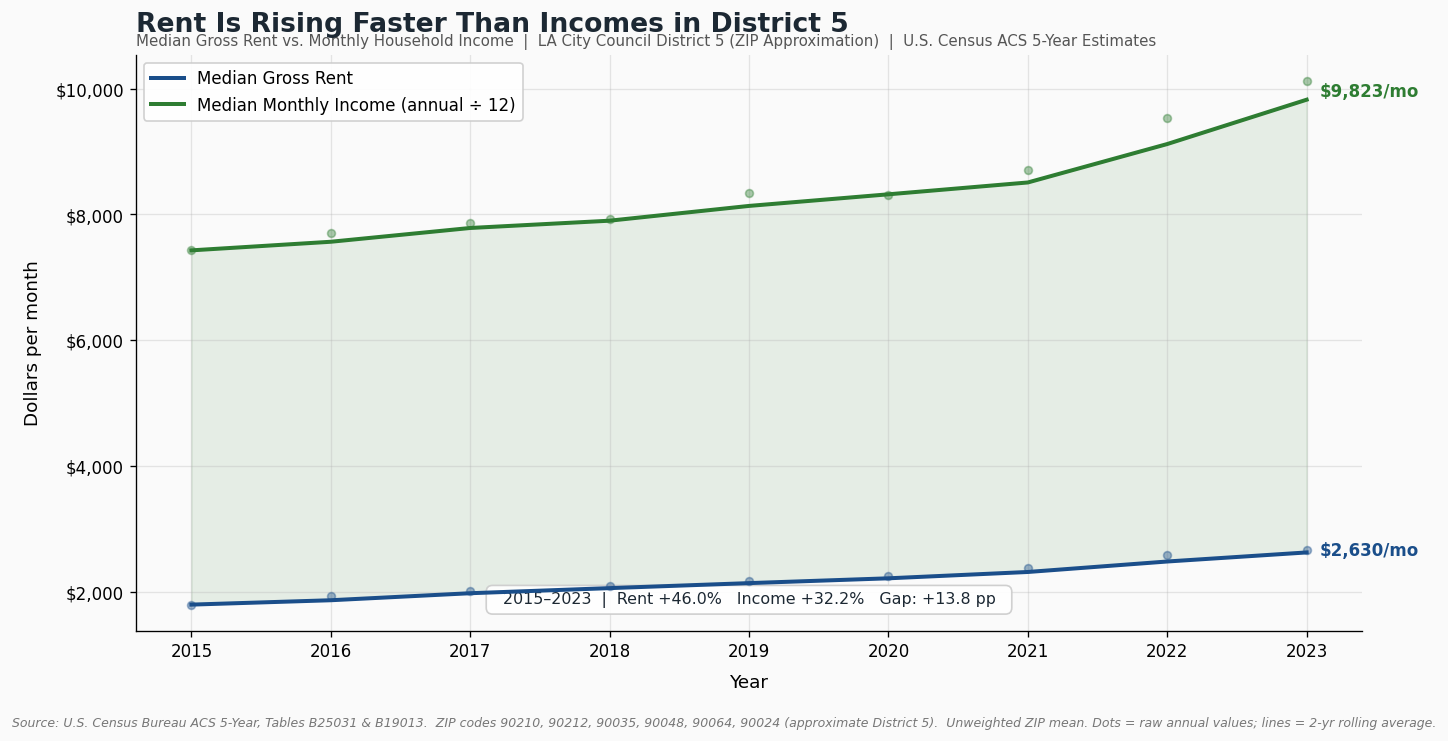

In [25]:
"""
Figure 1 — District 5: Rent vs. Monthly Income Trend
------------------------------------------------------
Campaign-quality chart showing how median rent and the monthly income
equivalent have moved over time, with a shaded gap to communicate
the growing affordability squeeze visually.
"""

if not metrics_df.empty:

    # ── Style constants ───────────────────────────────────────────────────────
    C_RENT    = "#1A4E8A"   # institutional navy  → rent
    C_INCOME  = "#2E7D32"   # forest green        → income
    C_GAP     = "#FFCDD2"   # light red           → gap fill (signals concern)
    C_TEXT    = "#1C2833"   # near-black for annotations
    ALPHA_RAW = 0.40        # raw data points: de-emphasised
    LW_MAIN   = 2.4         # main line weight

    monthly_income        = metrics_df["median_income"]        / 12
    monthly_income_smooth = metrics_df["income_smooth"] / 12

    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor("#FAFAFA")
    ax.set_facecolor("#FAFAFA")

    years = metrics_df["year"].values

    # ── Gap fill between smoothed rent and smoothed monthly income ────────────
    ax.fill_between(
        years,
        metrics_df["rent_smooth"],
        monthly_income_smooth,
        where=(monthly_income_smooth >= metrics_df["rent_smooth"]),
        alpha=0.10, color=C_INCOME, label="_nolegend_"
    )
    ax.fill_between(
        years,
        metrics_df["rent_smooth"],
        monthly_income_smooth,
        where=(monthly_income_smooth < metrics_df["rent_smooth"]),
        alpha=0.22, color=C_GAP, label="_nolegend_"
    )

    # ── Raw scatter points ────────────────────────────────────────────────────
    ax.scatter(years, metrics_df["median_rent"], s=22, alpha=ALPHA_RAW, color=C_RENT, zorder=4)
    ax.scatter(years, monthly_income,            s=22, alpha=ALPHA_RAW, color=C_INCOME, zorder=4)

    # ── Smoothed trend lines ──────────────────────────────────────────────────
    ax.plot(years, metrics_df["rent_smooth"],  color=C_RENT,   linewidth=LW_MAIN,
            label="Median Gross Rent", zorder=5)
    ax.plot(years, monthly_income_smooth,       color=C_INCOME, linewidth=LW_MAIN,
            label="Median Monthly Income (annual ÷ 12)", zorder=5)

    # ── End-point value labels ────────────────────────────────────────────────
    last = metrics_df.iloc[-1]
    last_yr = int(last["year"])
    last_rent   = last["rent_smooth"]
    last_income = last["income_smooth"] / 12
    ax.annotate(f"${last_rent:,.0f}/mo",
                xy=(last_yr, last_rent), xytext=(8, -2),
                textcoords="offset points", fontsize=10, fontweight="bold",
                color=C_RENT)
    ax.annotate(f"${last_income:,.0f}/mo",
                xy=(last_yr, last_income), xytext=(8, 2),
                textcoords="offset points", fontsize=10, fontweight="bold",
                color=C_INCOME)

    # ── Key stat callout box ──────────────────────────────────────────────────
    first = metrics_df.dropna(subset=["rent_smooth", "income_smooth"]).iloc[0]
    rent_chg   = ((last["rent_smooth"]   / first["rent_smooth"])   - 1) * 100
    income_chg = ((last["income_smooth"] / first["income_smooth"]) - 1) * 100
    gap_pp     = rent_chg - income_chg
    gap_str    = f"+{gap_pp:.1f} pp" if gap_pp > 0 else f"{gap_pp:.1f} pp"
    box_text   = (
        f"  {first['year']:.0f}–{last_yr}  |  "
        f"Rent +{rent_chg:.1f}%   Income +{income_chg:.1f}%   "
        f"Gap: {gap_str}  "
    )
    ax.text(0.5, 0.04, box_text,
            transform=ax.transAxes, ha="center", va="bottom",
            fontsize=9.5, color=C_TEXT,
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="#CCCCCC", alpha=0.92))

    # ── Axis & layout ─────────────────────────────────────────────────────────
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.set_xlabel("Year", fontsize=11, labelpad=8)
    ax.set_ylabel("Dollars per month", fontsize=11, labelpad=8)
    ax.set_xticks(years)
    ax.tick_params(axis="x", rotation=0, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

    ax.set_title(
        "Rent Is Rising Faster Than Incomes in District 5",
        fontsize=16, fontweight="bold", color=C_TEXT, pad=14, loc="left"
    )
    ax.text(0, 1.01,
            "Median Gross Rent vs. Monthly Household Income  |  "
            "LA City Council District 5 (ZIP Approximation)  |  "
            "U.S. Census ACS 5-Year Estimates",
            transform=ax.transAxes, fontsize=9, color="#555555", va="bottom")

    ax.legend(loc="upper left", fontsize=10, framealpha=0.9,
              edgecolor="#CCCCCC", fancybox=True)

    fig.text(0.5, -0.02,
             "Source: U.S. Census Bureau ACS 5-Year, Tables B25031 & B19013.  "
             "ZIP codes 90210, 90212, 90035, 90048, 90064, 90024 (approximate District 5).  "
             "Unweighted ZIP mean. Dots = raw annual values; lines = 2-yr rolling average.",
             ha="center", fontsize=7.5, color="#777777", style="italic")

    plt.tight_layout()
    plt.show()

else:
    print("⚠ No data to visualize. Please fetch or load data first.")

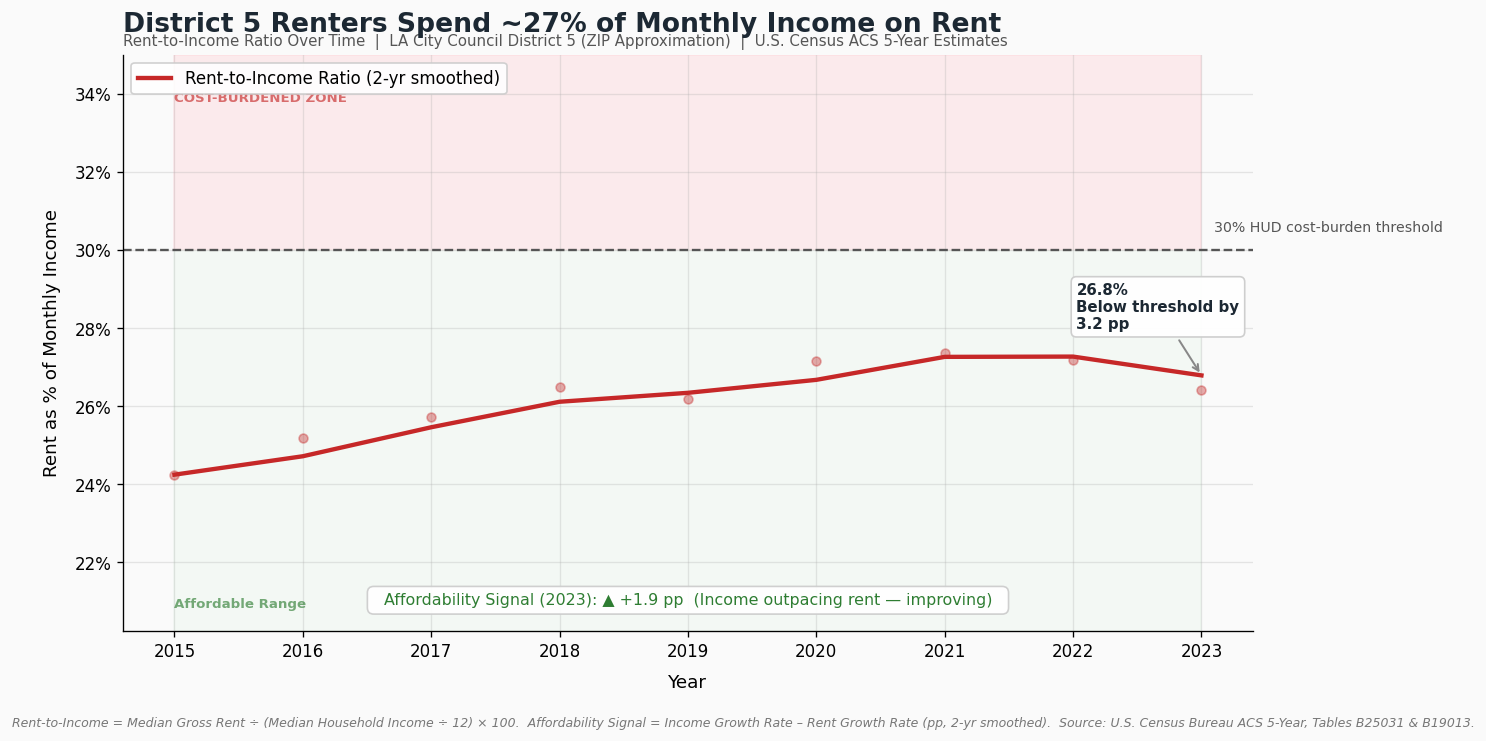

In [26]:
"""
Figure 2 — District 5: Rent-to-Income Ratio & Affordability Signal
-------------------------------------------------------------------
Campaign-quality visualization of the rent-to-income ratio over time.
The HUD 30% cost-burden threshold is the key reference marker.
The affordability signal (income growth − rent growth) is annotated
on the chart to contextualize the trend direction.
"""

if not metrics_df.empty:

    # ── Style constants ───────────────────────────────────────────────────────
    C_LINE      = "#C62828"   # deep red        → cost ratio line (urgency)
    C_BURDEN    = "#FFCDD2"   # light red fill  → cost-burden zone
    C_SAFE      = "#E8F5E9"   # light green     → below-threshold zone
    C_THRESH    = "#555555"   # medium gray     → 30% reference line
    C_TEXT      = "#1C2833"
    LW_MAIN     = 2.6
    THRESHOLD   = 30          # HUD cost-burden: spending >30% = cost-burdened

    years       = metrics_df["year"].values
    rti_raw     = metrics_df["rent_to_income"].values
    rti_smooth  = metrics_df["rent_to_income_smooth"].values
    y_ceil      = max(rti_raw.max(), THRESHOLD) + 5
    y_floor     = max(rti_raw.min() - 4, 0)

    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor("#FAFAFA")
    ax.set_facecolor("#FAFAFA")

    # ── Threshold zones ───────────────────────────────────────────────────────
    ax.fill_between(years, THRESHOLD, y_ceil,
                    color=C_BURDEN, alpha=0.35, label="_nolegend_", zorder=1)
    ax.fill_between(years, y_floor, THRESHOLD,
                    color=C_SAFE, alpha=0.35, label="_nolegend_", zorder=1)

    # ── HUD 30% reference line ────────────────────────────────────────────────
    ax.axhline(y=THRESHOLD, linestyle="--", linewidth=1.4, color=C_THRESH, zorder=2)
    ax.text(years[-1] + 0.1, THRESHOLD + 0.4,
            "30% HUD cost-burden threshold",
            fontsize=8.5, color=C_THRESH, va="bottom")

    # ── Zone labels ───────────────────────────────────────────────────────────
    ax.text(years[0], y_ceil - 1.2, "COST-BURDENED ZONE",
            fontsize=8, color="#C62828", alpha=0.65, fontweight="bold")
    ax.text(years[0], y_floor + 0.6, "Affordable Range",
            fontsize=8, color="#2E7D32", alpha=0.65, fontweight="bold")

    # ── Raw scatter points ────────────────────────────────────────────────────
    ax.scatter(years, rti_raw, s=28, color=C_LINE, alpha=0.38, zorder=4)

    # ── Smoothed line ─────────────────────────────────────────────────────────
    ax.plot(years, rti_smooth, color=C_LINE, linewidth=LW_MAIN,
            label="Rent-to-Income Ratio (2-yr smoothed)", zorder=5)

    # ── Current-year annotation ───────────────────────────────────────────────
    last_idx    = metrics_df.dropna(subset=["rent_to_income_smooth"]).index[-1]
    last        = metrics_df.loc[last_idx]
    cur_ratio   = last["rent_to_income_smooth"]
    cur_yr      = int(last["year"])
    signal_val  = last["afford_signal_smooth"]
    above_by    = cur_ratio - THRESHOLD
    status_str  = (f"↑ {above_by:.1f} pp above\ncost-burden threshold"
                   if above_by > 0 else f"Below threshold by\n{abs(above_by):.1f} pp")

    ax.annotate(
        f"{cur_ratio:.1f}%\n{status_str}",
        xy=(cur_yr, cur_ratio),
        xytext=(-75, 28), textcoords="offset points",
        fontsize=9, color=C_TEXT, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                  edgecolor="#CCCCCC", alpha=0.95),
        arrowprops=dict(arrowstyle="->", color="#888888", lw=1.2)
    )

    # ── Affordability signal callout ──────────────────────────────────────────
    if not pd.isna(signal_val):
        sig_color = "#2E7D32" if signal_val > 0 else "#C62828"
        sig_icon  = "▲" if signal_val > 0 else "▼"
        ax.text(0.5, 0.04,
                f"  Affordability Signal ({cur_yr}): {sig_icon} {signal_val:+.1f} pp  "
                f"({'Income outpacing rent — improving' if signal_val > 0 else 'Rent outpacing income — worsening'})  ",
                transform=ax.transAxes, ha="center", va="bottom",
                fontsize=9.5, color=sig_color,
                bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                          edgecolor="#CCCCCC", alpha=0.92))

    # ── Axis & layout ─────────────────────────────────────────────────────────
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.set_ylim(y_floor, y_ceil)
    ax.set_xlabel("Year", fontsize=11, labelpad=8)
    ax.set_ylabel("Rent as % of Monthly Income", fontsize=11, labelpad=8)
    ax.set_xticks(years)
    ax.tick_params(axis="x", rotation=0, labelsize=10)
    ax.tick_params(axis="y", labelsize=10)

    ax.set_title(
        f"District 5 Renters Spend ~{cur_ratio:.0f}% of Monthly Income on Rent",
        fontsize=16, fontweight="bold", color=C_TEXT, pad=14, loc="left"
    )
    ax.text(0, 1.01,
            "Rent-to-Income Ratio Over Time  |  "
            "LA City Council District 5 (ZIP Approximation)  |  "
            "U.S. Census ACS 5-Year Estimates",
            transform=ax.transAxes, fontsize=9, color="#555555", va="bottom")

    ax.legend(loc="upper left", fontsize=10, framealpha=0.9,
              edgecolor="#CCCCCC", fancybox=True)

    fig.text(0.5, -0.02,
             "Rent-to-Income = Median Gross Rent ÷ (Median Household Income ÷ 12) × 100.  "
             "Affordability Signal = Income Growth Rate – Rent Growth Rate (pp, 2-yr smoothed).  "
             "Source: U.S. Census Bureau ACS 5-Year, Tables B25031 & B19013.",
             ha="center", fontsize=7.5, color="#777777", style="italic")

    plt.tight_layout()
    plt.show()

else:
    print("⚠ No data to visualize. Please fetch or load data first.")

## Section 6 — Interpretation & Limitations

---

### What This Analysis Shows

- **Rent trend:** Whether District 5 median rents have risen, stabilized, or declined across the measured period. District 5 encompasses some of the highest-rent neighborhoods in Los Angeles; trends here reflect conditions in the city's most competitive rental submarkets.

- **Income trend:** Whether household incomes in the same area have kept pace with rising housing costs — the core question behind housing affordability.

- **Rent-to-Income ratio:** How much of a typical household's monthly budget is consumed by rent. The 30% threshold (HUD standard) marks the often-cited boundary of housing cost burden. A ratio above 30% and rising is a strong affordability warning signal for the district.

- **Affordability signal:** A heuristic indicator showing whether income growth or rent growth is "winning" year to year. It does not imply causation.

---

### What This Analysis Does NOT Show

| Claim | Why It's Out of Scope |
|---|---|
| "Rents are rising because of policy X" | This is correlation data only — no causal model |
| "District 5 will be unaffordable by Year Y" | No predictive model is applied |
| "All residents are cost-burdened" | Medians represent middle estimates; half of households pay more, half less |
| "These are exact District 5 figures" | ZIP code boundaries are proxies for council district lines |
| "This captures the full market" | ACS samples ~1–3% of households; estimates have margins of error |

---

### Data Assumptions & Known Limitations

1. **ACS Sampling Error:** The 5-year ACS pools ~15% of the population over five years, but estimates for small geographic areas carry significant margins of error. Year-to-year changes below ~2–3% may not be statistically meaningful.

2. **ZIP Code Geographic Approximation:** ZIP code boundaries do not match council district lines. Several ZIP codes in this analysis overlap with adjacent districts (CD4, CD11). The selected ZIPs represent the highest-confidence core of District 5.

3. **Unweighted Aggregation:** All ZIP codes are averaged without population weighting. ZIPs with small populations have equal weight to high-density ZIPs. A production model would weight by housing unit count or population.

4. **Rent Definition:** "Median Gross Rent" (ACS B25031) includes utilities and is self-reported by survey respondents. It may not fully reflect current market-rate rents, which can differ significantly from in-place rents in rent-stabilized buildings.

5. **Income Definition:** "Median Household Income" (ACS B19013) counts pre-tax earnings from all sources. It may include high-income outliers in District 5's wealthier neighborhoods, potentially understating affordability stress for lower-income residents.

---

### How This Expands Into a District Housing Dashboard

This prototype demonstrates the foundational data pipeline. A full district dashboard could extend this with:

| Feature | Data Source | Complexity |
|---|---|---|
| Cost-burden by income tier | ACS Table B25070 | Low |
| Renter vs. owner-occupied trends | ACS Table B25003 | Low |
| New housing permits by year | LA Open Data (LADBS) | Medium |
| Affordability by neighborhood within District 5 | Census tract–level ACS | Medium |
| Population displacement risk score | ACS + HMDA loan data | High |
| Interactive map of rent burden by tract | GeoPandas + LA GeoHub shapefiles | High |

---

*Prototype developed for civic awareness purposes. Data sourced from the U.S. Census Bureau American Community Survey (ACS). Not intended as a policy recommendation or econometric forecast.*

## Section 6 — Gaussian Process Forecast (2024–2028)

Gaussian Process Regression (GPR) is a non-parametric Bayesian method that fits a *distribution over functions* to the observed data. Rather than committing to a fixed functional form (e.g., linear trend), it captures whatever smooth pattern is present and propagates uncertainty into the forecast horizon.

**Kernel choice:** `Constant × RBF + WhiteKernel`
- The **Constant × RBF** component models smooth underlying trend with a learned length-scale.
- The **WhiteKernel** absorbs observation noise (Census sampling error, ZIP boundary mismatch).
- Bounds constrain length-scale to 1–20 years  — prevents under- or over-smoothing.

**Forecast horizon:** 2024–2028 (5 years forward from the latest ACS vintage).

**Interpretation:** Shaded bands show ±1σ and ±2σ posterior uncertainty. Wide bands in later years reflect the inherent difficulty of extrapolating a short 9-year series — treat as *plausible scenarios*, not point predictions.

In [27]:
"""
Gaussian Process Fitting
------------------------
Fit independent GPRs to: median rent, monthly income, rent-to-income ratio.
Forecast 2024-2028 with posterior mean and standard deviation.
"""
from sklearn.gaussian_process import GaussianProcessRegressor

# ── Year arrays ───────────────────────────────────────────────────────────────
FORE_YEARS = list(range(END_YEAR + 1, 2029))          # 2024-2028
ALL_YEARS  = YEARS + FORE_YEARS                         # 2015-2028

X_obs  = np.array(YEARS,      dtype=float).reshape(-1, 1)
X_fore = np.array(FORE_YEARS, dtype=float).reshape(-1, 1)
X_all  = np.array(ALL_YEARS,  dtype=float).reshape(-1, 1)


def fit_gp(y_obs: np.ndarray, n_restarts: int = 8) -> tuple:
    """
    Standardize y, fit GP with Constant*RBF + WhiteKernel, return
    (mu_all, sigma_all) over the full 2015-2028 range X_all.
    """
    mu_y, std_y = float(y_obs.mean()), float(y_obs.std()) + 1e-9
    y_std = (y_obs - mu_y) / std_y

    kernel = (
        C(1.0, (0.1, 10.0))
        * RBF(length_scale=3.0, length_scale_bounds=(1.0, 20.0))
        + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 2.0))
    )
    gpr = GaussianProcessRegressor(
        kernel=kernel, n_restarts_optimizer=n_restarts, normalize_y=False
    )
    gpr.fit(X_obs, y_std)

    mu_std, sigma_std = gpr.predict(X_all, return_std=True)
    mu    = mu_std   * std_y + mu_y
    sigma = sigma_std * std_y
    return mu, sigma


# ── Observed series training data (smoothed, matching the charts) ─────────────
y_rent     = metrics_df["rent_smooth"].values.astype(float)
y_income_m = (metrics_df["income_smooth"].values / 12).astype(float)   # monthly
y_rti      = metrics_df["rent_to_income_smooth"].values.astype(float)

# ── Fit ───────────────────────────────────────────────────────────────────────
rent_mu,   rent_sigma   = fit_gp(y_rent)
income_mu, income_sigma = fit_gp(y_income_m)
rti_mu,    rti_sigma    = fit_gp(y_rti)

# ── Index masks ───────────────────────────────────────────────────────────────
n_obs     = len(YEARS)
obs_mask  = np.arange(n_obs)
fore_mask = np.arange(n_obs, len(ALL_YEARS))
fore_x    = [ALL_YEARS[i] for i in fore_mask]

print("GP 2028 estimates:")
print(f"  Median rent:         ${rent_mu[-1]:,.0f}/mo  ± ${rent_sigma[-1]:,.0f}")
print(f"  Monthly income:      ${income_mu[-1]:,.0f}/mo  ± ${income_sigma[-1]:,.0f}")
print(f"  Rent-to-income:      {rti_mu[-1]:.1f}%        ± {rti_sigma[-1]:.1f} pp")

GP 2028 estimates:
  Median rent:         $2,381/mo  ± $280
  Monthly income:      $10,246/mo  ± $1,195
  Rent-to-income:      26.1%        ± 1.0 pp


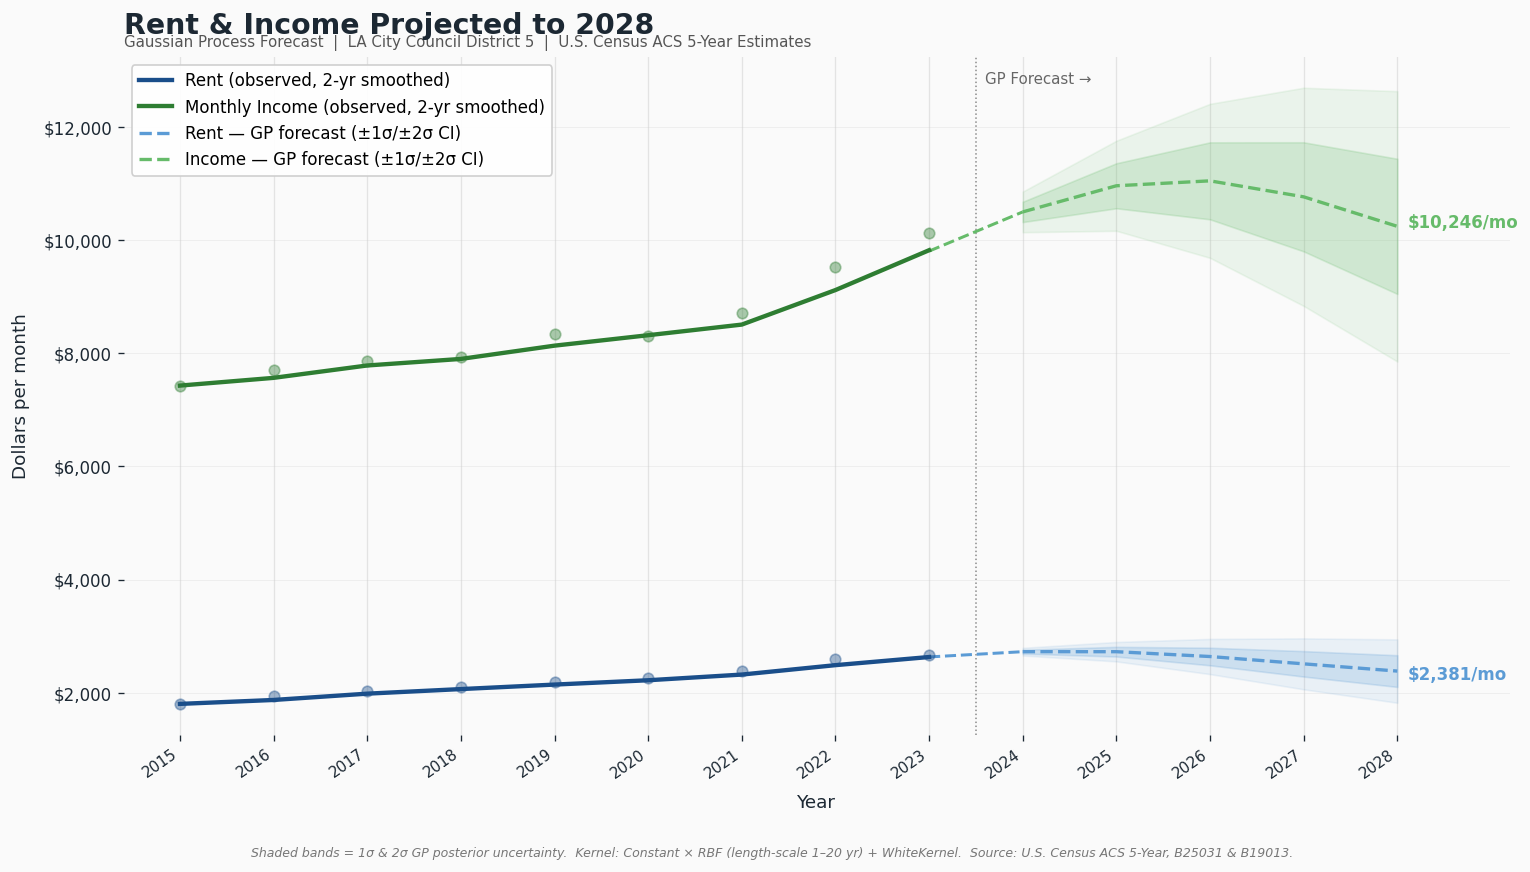

In [28]:
"""
Figure 3 — GP Projection: Rent & Monthly Income (2015-2028)
------------------------------------------------------------
Historical smoothed series + Gaussian Process forecast with
±1σ and ±2σ confidence bands through 2028.
"""
from matplotlib.lines import Line2D

BG = "#FAFAFA"

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

# ── Spine / tick styling ───────────────────────────────────────────────────────
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors=C_TEXT, labelsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("Year", fontsize=11, color=C_TEXT, labelpad=8)
ax.set_ylabel("Dollars per month", fontsize=11, color=C_TEXT, labelpad=8)
ax.grid(axis="y", color="#cccccc", linewidth=0.5, zorder=0)
ax.set_xlim(ALL_YEARS[0] - 0.6, ALL_YEARS[-1] + 1.2)
ax.set_xticks(ALL_YEARS)
ax.set_xticklabels([str(y) for y in ALL_YEARS], rotation=35, ha="right", fontsize=9)

# Forecast colours (lighter variants of chart colours)
C_FORE_RENT = "#5B9BD5"
C_FORE_INC  = "#66BB6A"

# ── Historical observed dots ───────────────────────────────────────────────────
ax.scatter(YEARS, metrics_df["median_rent"].values,
           color=C_RENT, s=40, alpha=ALPHA_RAW, zorder=7)
ax.scatter(YEARS, metrics_df["median_income"].values / 12,
           color=C_INCOME, s=40, alpha=ALPHA_RAW, zorder=7)

# ── Historical smoothed lines ──────────────────────────────────────────────────
ax.plot(YEARS, y_rent,     color=C_RENT,   lw=LW_MAIN, zorder=6)
ax.plot(YEARS, y_income_m, color=C_INCOME, lw=LW_MAIN, zorder=6)

# ── GP forecast: connect last observed → forecast, then dashed ────────────────
ax.plot([YEARS[-1], fore_x[0]],
        [rent_mu[n_obs - 1], rent_mu[n_obs]],
        color=C_FORE_RENT, lw=1.8, ls="--", zorder=5)
ax.plot([YEARS[-1], fore_x[0]],
        [income_mu[n_obs - 1], income_mu[n_obs]],
        color=C_FORE_INC, lw=1.8, ls="--", zorder=5)
ax.plot(fore_x, rent_mu[fore_mask],   color=C_FORE_RENT, lw=2.0, ls="--", zorder=5)
ax.plot(fore_x, income_mu[fore_mask], color=C_FORE_INC,  lw=2.0, ls="--", zorder=5)

# ── CI bands (±1σ lighter, ±2σ faint) ────────────────────────────────────────
for band, alpha in [(2, 0.10), (1, 0.20)]:
    ax.fill_between(fore_x,
                    rent_mu[fore_mask]   - band * rent_sigma[fore_mask],
                    rent_mu[fore_mask]   + band * rent_sigma[fore_mask],
                    color=C_FORE_RENT, alpha=alpha, zorder=2)
    ax.fill_between(fore_x,
                    income_mu[fore_mask] - band * income_sigma[fore_mask],
                    income_mu[fore_mask] + band * income_sigma[fore_mask],
                    color=C_FORE_INC, alpha=alpha, zorder=2)

# ── Vertical divider ──────────────────────────────────────────────────────────
ax.axvline(END_YEAR + 0.5, color="#888888", lw=0.9, ls=":", zorder=4)
ylims = ax.get_ylim()
ax.text(END_YEAR + 0.6, ylims[1] * 0.98,
        "GP Forecast →", fontsize=9, color="#666666", va="top")

# ── 2028 endpoint labels ───────────────────────────────────────────────────────
ax.annotate(f"${rent_mu[-1]:,.0f}/mo",
            xy=(ALL_YEARS[-1], rent_mu[-1]), xytext=(6, -2),
            textcoords="offset points",
            fontsize=10, fontweight="bold", color=C_FORE_RENT, va="center")
ax.annotate(f"${income_mu[-1]:,.0f}/mo",
            xy=(ALL_YEARS[-1], income_mu[-1]), xytext=(6, 2),
            textcoords="offset points",
            fontsize=10, fontweight="bold", color=C_FORE_INC, va="center")

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [
    Line2D([0], [0], color=C_RENT,       lw=LW_MAIN, label="Rent (observed, 2-yr smoothed)"),
    Line2D([0], [0], color=C_INCOME,     lw=LW_MAIN, label="Monthly Income (observed, 2-yr smoothed)"),
    Line2D([0], [0], color=C_FORE_RENT,  lw=2.0, ls="--", label="Rent — GP forecast (\u00b11\u03c3/\u00b12\u03c3 CI)"),
    Line2D([0], [0], color=C_FORE_INC,   lw=2.0, ls="--", label="Income — GP forecast (\u00b11\u03c3/\u00b12\u03c3 CI)"),
]
ax.legend(handles=handles, fontsize=10, frameon=True,
          framealpha=0.92, edgecolor="#CCCCCC", loc="upper left")

# ── Titles / footnote ─────────────────────────────────────────────────────────
ax.set_title("Rent & Income Projected to 2028",
             fontsize=17, fontweight="bold", color=C_TEXT, pad=14, loc="left")
ax.text(0, 1.01,
        "Gaussian Process Forecast  |  LA City Council District 5  |  "
        "U.S. Census ACS 5-Year Estimates",
        transform=ax.transAxes, fontsize=9, color="#555555", va="bottom")

fig.text(0.5, -0.03,
         "Shaded bands = 1\u03c3 & 2\u03c3 GP posterior uncertainty.  "
         "Kernel: Constant \u00d7 RBF (length-scale 1–20 yr) + WhiteKernel.  "
         "Source: U.S. Census ACS 5-Year, B25031 & B19013.",
         ha="center", fontsize=7.5, color="#777777", style="italic")

plt.tight_layout()
plt.show()

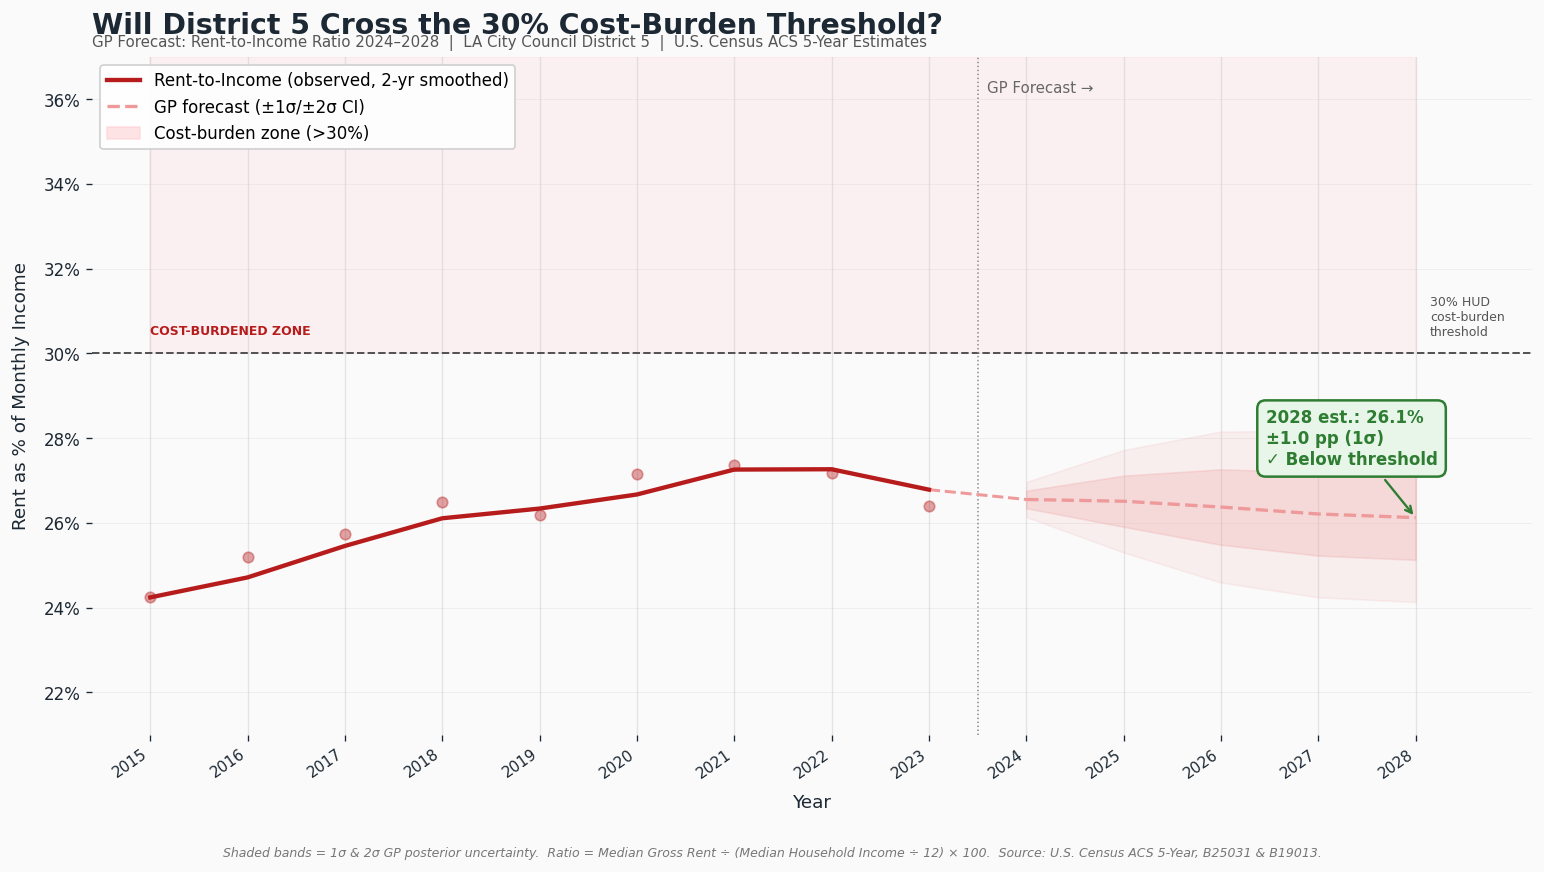

In [29]:
"""
Figure 4 — GP Projection: Rent-to-Income Ratio (2015-2028)
-----------------------------------------------------------
Will District 5 cross the HUD 30% cost-burden threshold by 2028?
GP posterior mean + CI bands with a dynamic callout annotation.
"""
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D as _L2D

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors=C_TEXT, labelsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.set_xlabel("Year", fontsize=11, color=C_TEXT, labelpad=8)
ax.set_ylabel("Rent as % of Monthly Income", fontsize=11, color=C_TEXT, labelpad=8)
ax.grid(axis="y", color="#cccccc", linewidth=0.5, zorder=0)
ax.set_xlim(ALL_YEARS[0] - 0.6, ALL_YEARS[-1] + 1.2)
ax.set_xticks(ALL_YEARS)
ax.set_xticklabels([str(y) for y in ALL_YEARS], rotation=35, ha="right", fontsize=9)

C_RTI      = "#B71C1C"
C_RTI_FORE = "#EF9A9A"
THRESH     = 30.0

# ── Dynamic y range ───────────────────────────────────────────────────────────
y_top = max(float(rti_mu.max()) + 3.5 * float(rti_sigma.max()), THRESH + 7)
y_bot = min(float(y_rti.min()) - 2.5, 21.0)
ax.set_ylim(y_bot, y_top)

# ── HUD 30% cost-burden zone ──────────────────────────────────────────────────
ax.axhline(THRESH, color="#555555", lw=1.2, ls="--", zorder=3)
ax.fill_between(ALL_YEARS, THRESH, y_top,
                color="#FFCDD2", alpha=0.22, zorder=1)
ax.text(ALL_YEARS[0], THRESH + 0.45,
        "COST-BURDENED ZONE", fontsize=7.5, color=C_RTI, fontweight="bold")
ax.text(ALL_YEARS[-1] + 0.15, THRESH + 0.35,
        "30% HUD\ncost-burden\nthreshold",
        fontsize=7.5, color="#555555", va="bottom", ha="left")

# ── Historical observed dots + smoothed line ───────────────────────────────────
ax.scatter(YEARS, metrics_df["rent_to_income"].values,
           color=C_RTI, s=40, alpha=ALPHA_RAW, zorder=7)
ax.plot(YEARS, y_rti, color=C_RTI, lw=LW_MAIN, zorder=6)

# ── GP connector + forecast ───────────────────────────────────────────────────
ax.plot([YEARS[-1], fore_x[0]],
        [rti_mu[n_obs - 1], rti_mu[n_obs]],
        color=C_RTI_FORE, lw=1.8, ls="--", zorder=5)
ax.plot(fore_x, rti_mu[fore_mask], color=C_RTI_FORE, lw=2.0, ls="--", zorder=5)

for band, alpha in [(2, 0.12), (1, 0.24)]:
    ax.fill_between(fore_x,
                    rti_mu[fore_mask] - band * rti_sigma[fore_mask],
                    rti_mu[fore_mask] + band * rti_sigma[fore_mask],
                    color=C_RTI_FORE, alpha=alpha, zorder=2)

# ── Vertical divider ──────────────────────────────────────────────────────────
ax.axvline(END_YEAR + 0.5, color="#888888", lw=0.9, ls=":", zorder=4)
ax.text(END_YEAR + 0.6, y_top * 0.985,
        "GP Forecast →", fontsize=9, color="#666666", va="top")

# ── 2028 dynamic callout ──────────────────────────────────────────────────────
proj_2028  = float(rti_mu[-1])
sig_2028   = float(rti_sigma[-1])
cross_30   = proj_2028 > THRESH
anno_fc    = "#FFCDD2" if cross_30 else "#E8F5E9"
anno_ec    = C_RTI if cross_30 else "#2E7D32"
anno_txt   = (
    f"2028 est.: {proj_2028:.1f}%\n"
    f"\u00b1{sig_2028:.1f} pp (1\u03c3)\n"
    + ("\u26a0 Cost-burdened" if cross_30 else "\u2713 Below threshold")
)
ax.annotate(anno_txt,
            xy=(2028, proj_2028), xytext=(-90, 32),
            textcoords="offset points",
            fontsize=10, fontweight="bold", color=anno_ec,
            bbox=dict(boxstyle="round,pad=0.5", fc=anno_fc, ec=anno_ec, lw=1.5),
            arrowprops=dict(arrowstyle="->", color=anno_ec, lw=1.4))

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [
    _L2D([0], [0], color=C_RTI,      lw=LW_MAIN, label="Rent-to-Income (observed, 2-yr smoothed)"),
    _L2D([0], [0], color=C_RTI_FORE, lw=2.0, ls="--", label="GP forecast (\u00b11\u03c3/\u00b12\u03c3 CI)"),
    mpatches.Patch(color="#FFCDD2", alpha=0.55, label="Cost-burden zone (>30%)"),
]
ax.legend(handles=handles, fontsize=10, frameon=True,
          framealpha=0.92, edgecolor="#CCCCCC", loc="upper left")

# ── Titles / footnote ─────────────────────────────────────────────────────────
ax.set_title(
    "Will District 5 Cross the 30% Cost-Burden Threshold?",
    fontsize=17, fontweight="bold", color=C_TEXT, pad=14, loc="left"
)
ax.text(0, 1.01,
        "GP Forecast: Rent-to-Income Ratio 2024–2028  |  "
        "LA City Council District 5  |  U.S. Census ACS 5-Year Estimates",
        transform=ax.transAxes, fontsize=9, color="#555555", va="bottom")

fig.text(0.5, -0.03,
         "Shaded bands = 1\u03c3 & 2\u03c3 GP posterior uncertainty.  "
         "Ratio = Median Gross Rent \u00f7 (Median Household Income \u00f7 12) \u00d7 100.  "
         "Source: U.S. Census ACS 5-Year, B25031 & B19013.",
         ha="center", fontsize=7.5, color="#777777", style="italic")

plt.tight_layout()
plt.show()